In [2]:
# Part 2 - Supervised Machine Learning Model
# Task 1: Load Cleaned Dataset and Define Features and Labels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

# Load cleaned dataset
df = pd.read_csv('/content/cleaned_data.csv')

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

# Regression target
y_reg = df['SalePrice']

# Binary classification target
y_clf = (y_reg > y_reg.median()).astype(int)

# Feature matrix
X = df.drop(columns=['SalePrice'])

print("\nRegression Label: SalePrice")
print("Regression target type:", y_reg.dtype)

print("\nClassification Label Definition:")
print("1 = SalePrice greater than median SalePrice")
print("0 = SalePrice less than or equal to median SalePrice")
print("Median SalePrice:", y_reg.median())

print("\nClassification Class Counts:")
print(y_clf.value_counts())

print("\nFeature Matrix Shape:", X.shape)

Dataset loaded successfully!
Dataset shape: (2197, 76)

Regression Label: SalePrice
Regression target type: int64

Classification Label Definition:
1 = SalePrice greater than median SalePrice
0 = SalePrice less than or equal to median SalePrice
Median SalePrice: 163500.0

Classification Class Counts:
SalePrice
0    1099
1    1098
Name: count, dtype: int64

Feature Matrix Shape: (2197, 75)


In [3]:
# Task 2: Encode Categorical Columns

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Number of categorical columns:", len(categorical_cols))
print("\nCategorical columns:")
print(categorical_cols)

# Define ordinal mappings for naturally ordered categories
ordinal_mappings = {
    'Exter Qual': {'Po': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    'Exter Cond': {'Po': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    'Bsmt Qual': {'Po': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    'Bsmt Cond': {'Po': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    'Heating QC': {'Po': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    'Kitchen Qual': {'Po': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    'Garage Qual': {'Po': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    'Garage Cond': {'Po': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4}
}

# Apply ordinal encoding
ordinal_encoded_cols = []

for col, mapping in ordinal_mappings.items():
    if col in X.columns:
        X[col] = X[col].map(mapping)
        ordinal_encoded_cols.append(col)

print("\nOrdinal encoded columns:")
print(ordinal_encoded_cols)

# Identify remaining categorical columns
remaining_categorical_cols = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("\nNumber of remaining nominal categorical columns:",
      len(remaining_categorical_cols))

# Apply one-hot encoding
X = pd.get_dummies(
    X,
    columns=remaining_categorical_cols,
    drop_first=True,
    dtype=int
)

print("\nEncoding completed successfully!")
print("Feature matrix shape after encoding:", X.shape)

print("\nRemaining non-numeric columns:")
print(X.select_dtypes(exclude=np.number).columns.tolist())

print("\nTotal missing values in encoded feature matrix:")
print(X.isnull().sum().sum())

Number of categorical columns: 37

Categorical columns:
['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Sale Type', 'Sale Condition']

Ordinal encoded columns:
['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'Heating QC', 'Kitchen Qual', 'Garage Qual', 'Garage Cond']

Number of remaining nominal categorical columns: 29

Encoding completed successfully!
Feature matrix shape after encoding: (2197, 221)

Remaining non-numeric columns:
[]

Total missing values in encoded feature matrix:
0


In [4]:
# Task 3: Leak-Free Train-Test Split and Scaling

# Regression train-test split
X_train_reg, X_test_reg, y_reg_train, y_reg_test = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Classification train-test split
X_train_clf, X_test_clf, y_clf_train, y_clf_test = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print("Regression Split:")
print("X_train shape:", X_train_reg.shape)
print("X_test shape:", X_test_reg.shape)
print("y_train shape:", y_reg_train.shape)
print("y_test shape:", y_reg_test.shape)

print("\nClassification Split:")
print("X_train shape:", X_train_clf.shape)
print("X_test shape:", X_test_clf.shape)
print("y_train shape:", y_clf_train.shape)
print("y_test shape:", y_clf_test.shape)

# Separate scalers for regression and classification
scaler_reg = StandardScaler()
scaler_clf = StandardScaler()

# Fit scalers ONLY on training features
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("\nScaling completed successfully.")

print("\nRegression scaled shapes:")
print("Training:", X_train_reg_scaled.shape)
print("Testing:", X_test_reg_scaled.shape)

print("\nClassification scaled shapes:")
print("Training:", X_train_clf_scaled.shape)
print("Testing:", X_test_clf_scaled.shape)

# Check classification class distribution
print("\nClassification Training Class Counts:")
print(y_clf_train.value_counts())

print("\nClassification Training Class Percentages:")
print(y_clf_train.value_counts(normalize=True) * 100)

Regression Split:
X_train shape: (1757, 221)
X_test shape: (440, 221)
y_train shape: (1757,)
y_test shape: (440,)

Classification Split:
X_train shape: (1757, 221)
X_test shape: (440, 221)
y_train shape: (1757,)
y_test shape: (440,)

Scaling completed successfully.

Regression scaled shapes:
Training: (1757, 221)
Testing: (440, 221)

Classification scaled shapes:
Training: (1757, 221)
Testing: (440, 221)

Classification Training Class Counts:
SalePrice
0    879
1    878
Name: count, dtype: int64

Classification Training Class Percentages:
SalePrice
0    50.028458
1    49.971542
Name: proportion, dtype: float64


In [5]:
# Task 4: Regression Models - Linear Regression and Ridge Regression

# Train Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_reg_scaled, y_reg_train)

# Predict on test data
y_pred_reg = linear_model.predict(X_test_reg_scaled)

# Evaluate Linear Regression
linear_mse = mean_squared_error(y_reg_test, y_pred_reg)
linear_r2 = r2_score(y_reg_test, y_pred_reg)

print("LINEAR REGRESSION RESULTS")
print("-------------------------")
print("Mean Squared Error (MSE):", linear_mse)
print("R-squared (R2):", linear_r2)

# Model coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})

coefficients['Absolute Coefficient'] = coefficients['Coefficient'].abs()

coefficients = coefficients.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

print("\nTop 3 Features with Largest Absolute Coefficients:")
print(coefficients.head(3))


# Train Ridge Regression model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_reg_scaled, y_reg_train)

# Predict using Ridge Regression
y_pred_ridge = ridge_model.predict(X_test_reg_scaled)

# Evaluate Ridge Regression
ridge_mse = mean_squared_error(y_reg_test, y_pred_ridge)
ridge_r2 = r2_score(y_reg_test, y_pred_ridge)

print("\nRIDGE REGRESSION RESULTS")
print("------------------------")
print("Mean Squared Error (MSE):", ridge_mse)
print("R-squared (R2):", ridge_r2)


# Comparison table
regression_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'MSE': [linear_mse, ridge_mse],
    'R2': [linear_r2, ridge_r2]
})

print("\nREGRESSION MODEL COMPARISON")
print("---------------------------")
print(regression_comparison)


# Compare coefficient profiles
ridge_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Ridge Coefficient': ridge_model.coef_
})

ridge_coefficients['Absolute Ridge Coefficient'] = (
    ridge_coefficients['Ridge Coefficient'].abs()
)

ridge_coefficients = ridge_coefficients.sort_values(
    by='Absolute Ridge Coefficient',
    ascending=False
)

print("\nTop 3 Ridge Features with Largest Absolute Coefficients:")
print(ridge_coefficients.head(3))

LINEAR REGRESSION RESULTS
-------------------------
Mean Squared Error (MSE): 964387322.1615368
R-squared (R2): 0.8178837979142809

Top 3 Features with Largest Absolute Coefficients:
          Feature    Coefficient  Absolute Coefficient
14   BsmtFin SF 1  143576.109044         143576.109044
16    Bsmt Unf SF  126048.611138         126048.611138
17  Total Bsmt SF -124004.685615         124004.685615

RIDGE REGRESSION RESULTS
------------------------
Mean Squared Error (MSE): 963372158.9212801
R-squared (R2): 0.8180755027091948

REGRESSION MODEL COMPARISON
---------------------------
               Model           MSE        R2
0  Linear Regression  9.643873e+08  0.817884
1   Ridge Regression  9.633722e+08  0.818076

Top 3 Ridge Features with Largest Absolute Coefficients:
               Feature  Ridge Coefficient  Absolute Ridge Coefficient
125  Roof Matl_CompShg       67316.937128                67316.937128
129  Roof Matl_Tar&Grv       50471.730146                50471.730146
131  Ro

CLASS DISTRIBUTION BEFORE MODEL TRAINING
----------------------------------------
SalePrice
0    879
1    878
Name: count, dtype: int64

Class Percentages:
SalePrice
0    50.028458
1    49.971542
Name: proportion, dtype: float64

Classes are sufficiently balanced.
Minority class percentage: 49.97154240182128
SMOTE or class_weight='balanced' is not required.

CONFUSION MATRIX
----------------
[[206  14]
 [  9 211]]

CLASSIFICATION REPORT
---------------------
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       220
           1       0.94      0.96      0.95       220

    accuracy                           0.95       440
   macro avg       0.95      0.95      0.95       440
weighted avg       0.95      0.95      0.95       440

ROC AUC Score: 0.9759814049586777


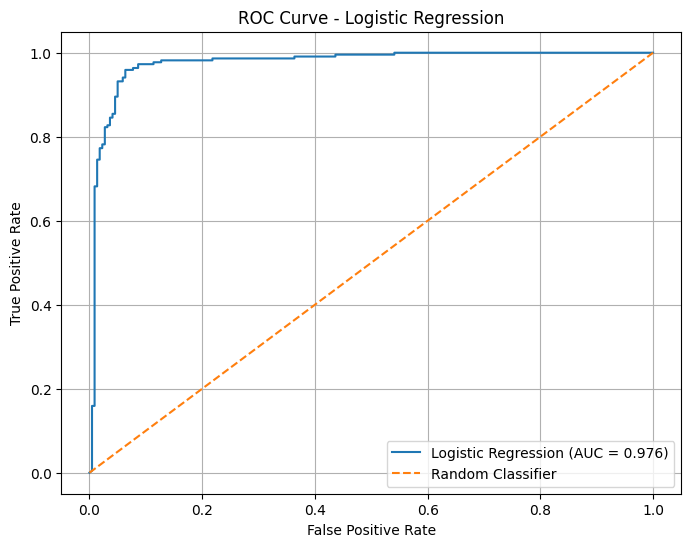

In [6]:
# Task 5: Classification Model - Logistic Regression

# Check class balance
print("CLASS DISTRIBUTION BEFORE MODEL TRAINING")
print("----------------------------------------")
print(y_clf_train.value_counts())

class_percentages = y_clf_train.value_counts(normalize=True) * 100

print("\nClass Percentages:")
print(class_percentages)

# Check whether class imbalance handling is required
minority_percentage = class_percentages.min()

if minority_percentage < 35:
    print("\nClass imbalance detected.")
    print("Minority class percentage:", minority_percentage)
    print("Class imbalance handling is required.")
else:
    print("\nClasses are sufficiently balanced.")
    print("Minority class percentage:", minority_percentage)
    print("SMOTE or class_weight='balanced' is not required.")


# Train Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(
    X_train_clf_scaled,
    y_clf_train
)

# Predict class labels
y_pred_clf = logistic_model.predict(X_test_clf_scaled)

# Predict class probabilities
y_proba_clf = logistic_model.predict_proba(
    X_test_clf_scaled
)[:, 1]


# Confusion Matrix
conf_matrix = confusion_matrix(
    y_clf_test,
    y_pred_clf
)

print("\nCONFUSION MATRIX")
print("----------------")
print(conf_matrix)


# Classification Report
print("\nCLASSIFICATION REPORT")
print("---------------------")
print(
    classification_report(
        y_clf_test,
        y_pred_clf
    )
)


# ROC AUC Score
auc_score = roc_auc_score(
    y_clf_test,
    y_proba_clf
)

print("ROC AUC Score:", auc_score)


# ROC Curve
fpr, tpr, thresholds = roc_curve(
    y_clf_test,
    y_proba_clf
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {auc_score:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid()

plt.show()

In [7]:
# Task 5(b): Decision-Threshold Sensitivity

# Define decision thresholds
decision_thresholds = np.arange(0.30, 0.71, 0.10)

threshold_results = []

for threshold in decision_thresholds:

    # Convert probabilities to class predictions
    y_pred_threshold = (
        y_proba_clf >= threshold
    ).astype(int)

    # Compute evaluation metrics
    precision = precision_score(
        y_clf_test,
        y_pred_threshold
    )

    recall = recall_score(
        y_clf_test,
        y_pred_threshold
    )

    f1 = f1_score(
        y_clf_test,
        y_pred_threshold
    )

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })


# Create threshold comparison table
threshold_table = pd.DataFrame(threshold_results)

print("DECISION-THRESHOLD SENSITIVITY ANALYSIS")
print("---------------------------------------")

print(
    threshold_table.to_string(
        index=False
    )
)


# Identify threshold with maximum F1 score
best_threshold_row = threshold_table.loc[
    threshold_table['F1 Score'].idxmax()
]

print("\nTHRESHOLD WITH MAXIMUM F1 SCORE")
print("--------------------------------")

print(
    "Threshold:",
    best_threshold_row['Threshold']
)

print(
    "Precision:",
    best_threshold_row['Precision']
)

print(
    "Recall:",
    best_threshold_row['Recall']
)

print(
    "F1 Score:",
    best_threshold_row['F1 Score']
)

DECISION-THRESHOLD SENSITIVITY ANALYSIS
---------------------------------------
 Threshold  Precision   Recall  F1 Score
       0.3   0.918103 0.968182  0.942478
       0.4   0.929515 0.959091  0.944072
       0.5   0.937778 0.959091  0.948315
       0.6   0.940639 0.936364  0.938497
       0.7   0.947867 0.909091  0.928074

THRESHOLD WITH MAXIMUM F1 SCORE
--------------------------------
Threshold: 0.5
Precision: 0.9377777777777778
Recall: 0.9590909090909091
F1 Score: 0.9483146067415731


In [8]:
# Task 6: Regularization Experiment on Logistic Regression

# Train strongly regularized Logistic Regression model
logistic_model_strong_reg = LogisticRegression(
    C=0.01,
    max_iter=1000
)

logistic_model_strong_reg.fit(
    X_train_clf_scaled,
    y_clf_train
)

# Predict class labels
y_pred_strong_reg = logistic_model_strong_reg.predict(
    X_test_clf_scaled
)

# Predict probabilities
y_proba_strong_reg = logistic_model_strong_reg.predict_proba(
    X_test_clf_scaled
)[:, 1]


# Baseline Logistic Regression metrics
baseline_precision = precision_score(
    y_clf_test,
    y_pred_clf
)

baseline_recall = recall_score(
    y_clf_test,
    y_pred_clf
)

baseline_auc = roc_auc_score(
    y_clf_test,
    y_proba_clf
)


# Strong regularization metrics
strong_reg_precision = precision_score(
    y_clf_test,
    y_pred_strong_reg
)

strong_reg_recall = recall_score(
    y_clf_test,
    y_pred_strong_reg
)

strong_reg_auc = roc_auc_score(
    y_clf_test,
    y_proba_strong_reg
)


# Comparison table
regularization_comparison = pd.DataFrame({
    'Model': [
        'Baseline Logistic Regression (C=1.0)',
        'Strong Regularization (C=0.01)'
    ],
    'Precision': [
        baseline_precision,
        strong_reg_precision
    ],
    'Recall': [
        baseline_recall,
        strong_reg_recall
    ],
    'AUC': [
        baseline_auc,
        strong_reg_auc
    ]
})

print("LOGISTIC REGRESSION REGULARIZATION COMPARISON")
print("---------------------------------------------")

print(
    regularization_comparison.to_string(
        index=False
    )
)


# Performance differences
print("\nPERFORMANCE CHANGE AFTER REDUCING C")
print("-----------------------------------")

print(
    "Precision change:",
    strong_reg_precision - baseline_precision
)

print(
    "Recall change:",
    strong_reg_recall - baseline_recall
)

print(
    "AUC change:",
    strong_reg_auc - baseline_auc
)

LOGISTIC REGRESSION REGULARIZATION COMPARISON
---------------------------------------------
                               Model  Precision   Recall      AUC
Baseline Logistic Regression (C=1.0)   0.937778 0.959091 0.975981
      Strong Regularization (C=0.01)   0.951220 0.886364 0.978306

PERFORMANCE CHANGE AFTER REDUCING C
-----------------------------------
Precision change: 0.013441734417344087
Recall change: -0.07272727272727275
AUC change: 0.0023243801652893525


In [9]:
# Task 7: Bootstrap Confidence Interval for AUC Difference

# Set random seed for reproducibility
np.random.seed(42)

n_bootstrap = 500
auc_differences = []

for i in range(n_bootstrap):

    # Draw bootstrap sample indices with replacement
    sample_indices = np.random.choice(
        len(y_clf_test),
        size=len(y_clf_test),
        replace=True
    )

    # Bootstrap true labels
    y_bootstrap = np.array(y_clf_test)[sample_indices]

    # Bootstrap predicted probabilities
    baseline_proba_bootstrap = y_proba_clf[sample_indices]

    strong_reg_proba_bootstrap = y_proba_strong_reg[
        sample_indices
    ]

    # Compute AUC only if both classes are present
    if len(np.unique(y_bootstrap)) == 2:

        baseline_auc_bootstrap = roc_auc_score(
            y_bootstrap,
            baseline_proba_bootstrap
        )

        strong_reg_auc_bootstrap = roc_auc_score(
            y_bootstrap,
            strong_reg_proba_bootstrap
        )

        # AUC difference: C=1.0 minus C=0.01
        auc_difference = (
            baseline_auc_bootstrap
            - strong_reg_auc_bootstrap
        )

        auc_differences.append(auc_difference)


# Convert to NumPy array
auc_differences = np.array(auc_differences)


# Calculate bootstrap statistics
mean_auc_difference = np.mean(auc_differences)

lower_bound = np.percentile(
    auc_differences,
    2.5
)

upper_bound = np.percentile(
    auc_differences,
    97.5
)


# Print results
print("BOOTSTRAP CONFIDENCE INTERVAL FOR AUC DIFFERENCE")
print("------------------------------------------------")

print(
    "Number of bootstrap samples:",
    len(auc_differences)
)

print(
    "Mean AUC Difference (C=1.0 - C=0.01):",
    mean_auc_difference
)

print(
    "2.5th Percentile:",
    lower_bound
)

print(
    "97.5th Percentile:",
    upper_bound
)

print(
    "95% Confidence Interval:",
    (lower_bound, upper_bound)
)


# Interpret whether interval includes zero
if lower_bound <= 0 <= upper_bound:

    print(
        "\nThe 95% confidence interval includes zero."
    )

    print(
        "The AUC difference between the two models "
        "may not be statistically reliable."
    )

else:

    print(
        "\nThe 95% confidence interval excludes zero."
    )

    print(
        "The AUC difference between the two models "
        "appears consistently different across "
        "bootstrap samples."
    )

BOOTSTRAP CONFIDENCE INTERVAL FOR AUC DIFFERENCE
------------------------------------------------
Number of bootstrap samples: 500
Mean AUC Difference (C=1.0 - C=0.01): -0.002454869386492127
2.5th Percentile: -0.009664685434314011
97.5th Percentile: 0.0038591741864916445
95% Confidence Interval: (np.float64(-0.009664685434314011), np.float64(0.0038591741864916445))

The 95% confidence interval includes zero.
The AUC difference between the two models may not be statistically reliable.


In [10]:
# Part 3 - Task 1: Decision Tree Baseline

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Train unconstrained Decision Tree
decision_tree_baseline = DecisionTreeClassifier(random_state=42)

decision_tree_baseline.fit(X_train_clf_scaled, y_clf_train)

# Predictions
y_train_pred_tree = decision_tree_baseline.predict(X_train_clf_scaled)
y_test_pred_tree = decision_tree_baseline.predict(X_test_clf_scaled)

# Accuracy
tree_train_accuracy = accuracy_score(y_clf_train, y_train_pred_tree)
tree_test_accuracy = accuracy_score(y_clf_test, y_test_pred_tree)

print("DECISION TREE BASELINE RESULTS")
print("--------------------------------")

print("Training Accuracy:", tree_train_accuracy)
print("Test Accuracy:", tree_test_accuracy)

print("\nTrain-Test Accuracy Gap:")
print(tree_train_accuracy - tree_test_accuracy)

DECISION TREE BASELINE RESULTS
--------------------------------
Training Accuracy: 1.0
Test Accuracy: 0.8772727272727273

Train-Test Accuracy Gap:
0.12272727272727268


In [11]:
# Part 3 - Task 2: Controlled Decision Tree

# Train controlled Decision Tree
decision_tree_controlled = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

decision_tree_controlled.fit(X_train_clf_scaled, y_clf_train)

# Predictions
y_train_pred_controlled = decision_tree_controlled.predict(X_train_clf_scaled)
y_test_pred_controlled = decision_tree_controlled.predict(X_test_clf_scaled)

# Accuracy
controlled_train_accuracy = accuracy_score(
    y_clf_train,
    y_train_pred_controlled
)

controlled_test_accuracy = accuracy_score(
    y_clf_test,
    y_test_pred_controlled
)

# Train-test gaps
baseline_gap = tree_train_accuracy - tree_test_accuracy
controlled_gap = controlled_train_accuracy - controlled_test_accuracy

print("CONTROLLED DECISION TREE RESULTS")
print("--------------------------------")

print("Training Accuracy:", controlled_train_accuracy)
print("Test Accuracy:", controlled_test_accuracy)

print("\nTrain-Test Accuracy Gap:")
print(controlled_gap)

print("\nDECISION TREE COMPARISON")
print("--------------------------------")

print("Unconstrained Tree Gap:", baseline_gap)
print("Controlled Tree Gap:", controlled_gap)

CONTROLLED DECISION TREE RESULTS
--------------------------------
Training Accuracy: 0.92942515651679
Test Accuracy: 0.8977272727272727

Train-Test Accuracy Gap:
0.03169788378951732

DECISION TREE COMPARISON
--------------------------------
Unconstrained Tree Gap: 0.12272727272727268
Controlled Tree Gap: 0.03169788378951732


In [12]:
# Part 3 - Task 3: Gini vs Entropy Comparison

# Decision Tree using Gini impurity
gini_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

gini_tree.fit(X_train_clf_scaled, y_clf_train)

gini_predictions = gini_tree.predict(X_test_clf_scaled)

gini_accuracy = accuracy_score(
    y_clf_test,
    gini_predictions
)


# Decision Tree using Entropy
entropy_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

entropy_tree.fit(X_train_clf_scaled, y_clf_train)

entropy_predictions = entropy_tree.predict(X_test_clf_scaled)

entropy_accuracy = accuracy_score(
    y_clf_test,
    entropy_predictions
)


# Display Results
print("GINI VS ENTROPY COMPARISON")
print("--------------------------------")

print("Gini Test Accuracy:", gini_accuracy)
print("Entropy Test Accuracy:", entropy_accuracy)

print("\nAccuracy Difference:")
print(abs(gini_accuracy - entropy_accuracy))

GINI VS ENTROPY COMPARISON
--------------------------------
Gini Test Accuracy: 0.8909090909090909
Entropy Test Accuracy: 0.8909090909090909

Accuracy Difference:
0.0


In [13]:
# Part 3 - Task 4: Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# Train Random Forest
random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

random_forest.fit(X_train_clf_scaled, y_clf_train)

# Predictions
rf_train_predictions = random_forest.predict(X_train_clf_scaled)
rf_test_predictions = random_forest.predict(X_test_clf_scaled)

# Predicted probabilities
rf_test_probabilities = random_forest.predict_proba(
    X_test_clf_scaled
)[:, 1]

# Evaluation metrics
rf_train_accuracy = accuracy_score(
    y_clf_train,
    rf_train_predictions
)

rf_test_accuracy = accuracy_score(
    y_clf_test,
    rf_test_predictions
)

rf_auc = roc_auc_score(
    y_clf_test,
    rf_test_probabilities
)

print("RANDOM FOREST RESULTS")
print("--------------------------------")

print("Training Accuracy:", rf_train_accuracy)
print("Test Accuracy:", rf_test_accuracy)
print("ROC-AUC Score:", rf_auc)


# Feature Importances
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

top_5_features = feature_importance_df.head(5)

print("\nTOP 5 FEATURES BY IMPORTANCE")
print("--------------------------------")

print(top_5_features)

RANDOM FOREST RESULTS
--------------------------------
Training Accuracy: 0.9943084803642572
Test Accuracy: 0.9227272727272727
ROC-AUC Score: 0.9816735537190083

TOP 5 FEATURES BY IMPORTANCE
--------------------------------
          Feature  Importance
5    Overall Qual    0.100206
22    Gr Liv Area    0.059564
7      Year Built    0.053583
32  Garage Yr Blt    0.048437
10     Exter Qual    0.045618


In [14]:
# Part 3 - Task 4a: Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

# Train Gradient Boosting model
gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting.fit(X_train_clf_scaled, y_clf_train)

# Predictions
gb_train_predictions = gradient_boosting.predict(X_train_clf_scaled)
gb_test_predictions = gradient_boosting.predict(X_test_clf_scaled)

# Predicted probabilities
gb_test_probabilities = gradient_boosting.predict_proba(
    X_test_clf_scaled
)[:, 1]

# Evaluation metrics
gb_train_accuracy = accuracy_score(
    y_clf_train,
    gb_train_predictions
)

gb_test_accuracy = accuracy_score(
    y_clf_test,
    gb_test_predictions
)

gb_auc = roc_auc_score(
    y_clf_test,
    gb_test_probabilities
)

print("GRADIENT BOOSTING RESULTS")
print("--------------------------------")

print("Training Accuracy:", gb_train_accuracy)
print("Test Accuracy:", gb_test_accuracy)
print("ROC-AUC Score:", gb_auc)

GRADIENT BOOSTING RESULTS
--------------------------------
Training Accuracy: 0.9840637450199203
Test Accuracy: 0.9340909090909091
ROC-AUC Score: 0.979814049586777


In [15]:
# Part 3 - Task 4b: Feature Ablation Study

# Identify 5 lowest-importance Random Forest features
bottom_5_features = feature_importance_df.tail(5)['Feature'].tolist()

print("5 LOWEST-IMPORTANCE FEATURES")
print("--------------------------------")
print(bottom_5_features)

# Create reduced feature matrix by removing bottom 5 features
X_reduced = X.drop(columns=bottom_5_features)

# Use the same train and test row indices as the original split
X_train_reduced = X_reduced.loc[X_train_clf.index]
X_test_reduced = X_reduced.loc[X_test_clf.index]

# Scale reduced features using training data only
scaler_reduced = StandardScaler()

X_train_reduced_scaled = scaler_reduced.fit_transform(
    X_train_reduced
)

X_test_reduced_scaled = scaler_reduced.transform(
    X_test_reduced
)

# Train Random Forest on reduced feature set
random_forest_reduced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

random_forest_reduced.fit(
    X_train_reduced_scaled,
    y_clf_train
)

# Predict probabilities
rf_reduced_probabilities = random_forest_reduced.predict_proba(
    X_test_reduced_scaled
)[:, 1]

# Calculate ROC-AUC
rf_reduced_auc = roc_auc_score(
    y_clf_test,
    rf_reduced_probabilities
)

# Compare full and reduced models
print("\nFEATURE ABLATION RESULTS")
print("--------------------------------")

print("Full Feature Count:", X.shape[1])
print("Reduced Feature Count:", X_reduced.shape[1])

print("\nFull Random Forest ROC-AUC:", rf_auc)
print("Reduced Random Forest ROC-AUC:", rf_reduced_auc)

print("\nROC-AUC Difference (Reduced - Full):")
print(rf_reduced_auc - rf_auc)

5 LOWEST-IMPORTANCE FEATURES
--------------------------------
['Electrical_Mix', 'Sale Type_ConLw', 'Sale Type_ConLI', 'Sale Type_Con', 'Sale Condition_AdjLand']

FEATURE ABLATION RESULTS
--------------------------------
Full Feature Count: 221
Reduced Feature Count: 216

Full Random Forest ROC-AUC: 0.9816735537190083
Reduced Random Forest ROC-AUC: 0.9803305785123968

ROC-AUC Difference (Reduced - Full):
-0.0013429752066115297


In [16]:
# Part 3 - Task 5: 5-Fold Cross-Validation

from sklearn.model_selection import cross_val_score, StratifiedKFold

# Define stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Controlled Decision Tree CV
tree_cv_scores = cross_val_score(
    decision_tree_controlled,
    X_train_clf_scaled,
    y_clf_train,
    cv=cv,
    scoring='roc_auc'
)

# Random Forest CV
rf_cv_scores = cross_val_score(
    random_forest,
    X_train_clf_scaled,
    y_clf_train,
    cv=cv,
    scoring='roc_auc'
)

# Gradient Boosting CV
gb_cv_scores = cross_val_score(
    gradient_boosting,
    X_train_clf_scaled,
    y_clf_train,
    cv=cv,
    scoring='roc_auc'
)

# Create comparison table
cv_comparison = pd.DataFrame({
    'Model': [
        'Controlled Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Mean CV ROC-AUC': [
        tree_cv_scores.mean(),
        rf_cv_scores.mean(),
        gb_cv_scores.mean()
    ],
    'CV ROC-AUC Std': [
        tree_cv_scores.std(),
        rf_cv_scores.std(),
        gb_cv_scores.std()
    ]
})

print("5-FOLD CROSS-VALIDATION RESULTS")
print("--------------------------------")

print(cv_comparison.to_string(index=False))

print("\nINDIVIDUAL FOLD ROC-AUC SCORES")
print("--------------------------------")

print("Controlled Decision Tree:", tree_cv_scores)
print("Random Forest:", rf_cv_scores)
print("Gradient Boosting:", gb_cv_scores)

5-FOLD CROSS-VALIDATION RESULTS
--------------------------------
                   Model  Mean CV ROC-AUC  CV ROC-AUC Std
Controlled Decision Tree         0.938457        0.014527
           Random Forest         0.981130        0.006510
       Gradient Boosting         0.981041        0.005779

INDIVIDUAL FOLD ROC-AUC SCORES
--------------------------------
Controlled Decision Tree: [0.94576446 0.94127712 0.93961039 0.95436688 0.91126623]
Random Forest: [0.98411674 0.98176007 0.97191558 0.99107143 0.97678571]
Gradient Boosting: [0.98410059 0.98250258 0.97935065 0.98824675 0.97100649]


In [17]:
# Part 3 - Task 6: Hyperparameter Tuning with GridSearchCV

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Build pipeline
rf_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parameter grid
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, None],
    'randomforestclassifier__min_samples_leaf': [1, 5]
}

# Stratified 5-fold cross-validation
grid_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=grid_cv,
    scoring='roc_auc',
    n_jobs=-1
)

# Train on UNSCALED training data
grid_search.fit(X_train_clf, y_clf_train)

# Best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_pipeline = grid_search.best_estimator_

print("GRIDSEARCHCV RESULTS")
print("--------------------------------")

print("Total Model Configurations Evaluated:", len(grid_search.cv_results_['params']))
print("Expected Grid Size: 3 x 3 x 2 = 18")

print("\nBest Parameters:")
print(best_params)

print("\nBest Cross-Validated ROC-AUC Score:")
print(best_score)

GRIDSEARCHCV RESULTS
--------------------------------
Total Model Configurations Evaluated: 18
Expected Grid Size: 3 x 3 x 2 = 18

Best Parameters:
{'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 200}

Best Cross-Validated ROC-AUC Score:
0.9818103231995277


In [18]:
# Part 3 - Task 7: Manual Learning Curve

from sklearn.metrics import roc_auc_score
import pandas as pd

# Training-set fractions required by the assignment
train_fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

learning_curve_results = []

for fraction in train_fractions:

    # Number of training samples to use
    n_train = int(fraction * len(X_train_clf))

    # Take progressively larger subsets of training data
    X_subset = X_train_clf.iloc[:n_train]
    y_subset = y_clf_train.iloc[:n_train]

    # Refit the best pipeline found by GridSearchCV
    best_pipeline.fit(X_subset, y_subset)

    # Training probabilities
    y_train_proba = best_pipeline.predict_proba(X_subset)[:, 1]

    # Test probabilities
    y_test_proba = best_pipeline.predict_proba(X_test_clf)[:, 1]

    # Compute ROC-AUC
    train_auc = roc_auc_score(y_subset, y_train_proba)
    test_auc = roc_auc_score(y_clf_test, y_test_proba)

    learning_curve_results.append({
        'Training Fraction': fraction,
        'Training AUC': train_auc,
        'Test AUC': test_auc
    })


# Create results table
learning_curve_table = pd.DataFrame(learning_curve_results)

print("MANUAL LEARNING CURVE RESULTS")
print("--------------------------------")

print(learning_curve_table.to_string(index=False))

MANUAL LEARNING CURVE RESULTS
--------------------------------
 Training Fraction  Training AUC  Test AUC
               0.2      1.000000  0.976250
               0.4      1.000000  0.981715
               0.6      0.999946  0.981798
               0.8      0.999901  0.984835
               1.0      0.999648  0.982314


In [19]:
# Part 3 - Task 8: Serialize the Best Model

import joblib
import os

# Refit the best pipeline on the complete training dataset
best_pipeline.fit(X_train_clf, y_clf_train)

# Save the trained best pipeline
joblib.dump(best_pipeline, 'best_model.pkl')

print("BEST MODEL SERIALIZATION")
print("--------------------------------")

print("Best model saved successfully as best_model.pkl")

print("\nSaved Model File Size:")
print(os.path.getsize('best_model.pkl'), "bytes")


# Reload the saved model
loaded_model = joblib.load('best_model.pkl')

# Predict two handcrafted test rows
sample_rows = X_test_clf.iloc[:2]

sample_predictions = loaded_model.predict(sample_rows)
sample_probabilities = loaded_model.predict_proba(sample_rows)[:, 1]

print("\nRELOAD-AND-PREDICT TEST")
print("--------------------------------")

print("Predictions for two sample rows:")
print(sample_predictions)

print("\nPredicted probabilities for class 1:")
print(sample_probabilities)

print("\nReload-and-predict test completed successfully.")

BEST MODEL SERIALIZATION
--------------------------------
Best model saved successfully as best_model.pkl

Saved Model File Size:
3951874 bytes

RELOAD-AND-PREDICT TEST
--------------------------------
Predictions for two sample rows:
[1 0]

Predicted probabilities for class 1:
[0.96665595 0.05929494]

Reload-and-predict test completed successfully.


In [20]:
# Part 3 - Task 9: Summary Model Comparison Table

from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import pandas as pd

# Logistic Regression 5-fold CV
logistic_cv_scores = cross_val_score(
    logistic_model,
    X_train_clf_scaled,
    y_clf_train,
    cv=cv,
    scoring='roc_auc'
)

# Calculate all test ROC-AUC scores directly

logistic_test_auc = roc_auc_score(
    y_clf_test,
    logistic_model.predict_proba(X_test_clf_scaled)[:, 1]
)

tree_test_auc = roc_auc_score(
    y_clf_test,
    decision_tree_controlled.predict_proba(X_test_clf_scaled)[:, 1]
)

rf_test_auc = roc_auc_score(
    y_clf_test,
    random_forest.predict_proba(X_test_clf_scaled)[:, 1]
)

gb_test_auc = roc_auc_score(
    y_clf_test,
    gradient_boosting.predict_proba(X_test_clf_scaled)[:, 1]
)

# Final model comparison table
final_model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Controlled Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    '5-Fold CV Mean AUC': [
        logistic_cv_scores.mean(),
        tree_cv_scores.mean(),
        rf_cv_scores.mean(),
        gb_cv_scores.mean()
    ],
    '5-Fold CV AUC Std': [
        logistic_cv_scores.std(),
        tree_cv_scores.std(),
        rf_cv_scores.std(),
        gb_cv_scores.std()
    ],
    'Test AUC': [
        logistic_test_auc,
        tree_test_auc,
        rf_test_auc,
        gb_test_auc
    ]
})

print("FINAL MODEL COMPARISON")
print("--------------------------------")

print(final_model_comparison.to_string(index=False))

# Identify best model by mean CV AUC
best_model_row = final_model_comparison.loc[
    final_model_comparison['5-Fold CV Mean AUC'].idxmax()
]

print("\nRECOMMENDED MODEL")
print("--------------------------------")

print("Model:", best_model_row['Model'])
print("Mean CV ROC-AUC:", best_model_row['5-Fold CV Mean AUC'])
print(
    "CV ROC-AUC Standard Deviation:",
    best_model_row['5-Fold CV AUC Std']
)
print("Test ROC-AUC:", best_model_row['Test AUC'])

FINAL MODEL COMPARISON
--------------------------------
                   Model  5-Fold CV Mean AUC  5-Fold CV AUC Std  Test AUC
     Logistic Regression            0.974346           0.009301  0.975981
Controlled Decision Tree            0.938457           0.014527  0.940671
           Random Forest            0.981130           0.006510  0.981674
       Gradient Boosting            0.981041           0.005779  0.979814

RECOMMENDED MODEL
--------------------------------
Model: Random Forest
Mean CV ROC-AUC: 0.9811299070247935
CV ROC-AUC Standard Deviation: 0.006510420189470216
Test ROC-AUC: 0.9816735537190083


# Part 4 — LLM-Powered Model Prediction Explanation

## Selected Track: Track C — Model Prediction Explanation Pipeline

This part extends the machine learning workflow developed in Parts 1–3 by integrating a Large Language Model (LLM) with the best-performing Random Forest prediction pipeline.

The trained model is used to generate a predicted class and predicted probability for hand-crafted housing feature inputs. These prediction results are then supplied to an LLM through a structured prompt. The LLM returns a validated JSON explanation containing the prediction label, confidence level, top reason, second reason, and recommended next step.

A schema-validation layer is used to ensure structured output, while a personally identifiable information (PII) guardrail checks user inputs before every LLM API call.

In [21]:
# Part 4 - Task 1: LLM API Setup

import os
import json
import re
import requests
import joblib

from jsonschema import validate, ValidationError

print("Part 4 libraries imported successfully.")

# API key must be stored in an environment variable
api_key = os.environ.get("LLM_API_KEY")

if api_key:
    print("LLM_API_KEY environment variable detected.")
else:
    print("LLM_API_KEY is not currently set.")

Part 4 libraries imported successfully.
LLM_API_KEY is not currently set.


In [22]:
# Part 4 - Task 1A: Secure API Key Setup

import getpass

if not os.environ.get("LLM_API_KEY"):
    os.environ["LLM_API_KEY"] = getpass.getpass(
        "Enter your LLM API key securely: "
    )

api_key = os.environ.get("LLM_API_KEY")

if api_key:
    print("LLM_API_KEY configured successfully for this notebook session.")
else:
    print("LLM_API_KEY configuration failed.")

Enter your LLM API key securely: ··········
LLM_API_KEY configured successfully for this notebook session.


In [23]:
# Part 4 - Task 1B: Reusable LLM API Function

LLM_URL = "https://openrouter.ai/api/v1/chat/completions"

MODEL_NAME = "openai/gpt-4o-mini"


def call_llm(system_prompt, user_prompt, temperature=0.0, max_tokens=512):
    api_key = os.environ.get("LLM_API_KEY")

    if not api_key:
        print("Error: LLM_API_KEY is not configured.")
        return None

    payload = {
        "model": MODEL_NAME,
        "messages": [
            {
                "role": "system",
                "content": system_prompt
            },
            {
                "role": "user",
                "content": user_prompt
            }
        ],
        "temperature": temperature,
        "max_tokens": max_tokens
    }

    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }

    try:
        response = requests.post(
            LLM_URL,
            headers=headers,
            json=payload
        )

        if response.status_code != 200:
            print("LLM API request failed.")
            print("Status code:", response.status_code)
            print("Response:", response.text)
            return None

        return response.json()["choices"][0]["message"]["content"]

    except requests.RequestException as error:
        print("LLM API connection error:", error)
        return None


# Simple API Test

test_system_prompt = (
    "You are a precise assistant. Follow the user's instruction exactly."
)

test_user_prompt = "Reply with only the word hello"

test_response = call_llm(
    test_system_prompt,
    test_user_prompt,
    temperature=0.0,
    max_tokens=20
)

print("LLM TEST RESPONSE")
print("------------------------------")
print(test_response)

LLM TEST RESPONSE
------------------------------
hello


In [24]:
# Part 4 - Task 2: Track C Prompt Design

TRACK_CHOICE = "Track C - Model Prediction Explanation Pipeline"

print("SELECTED PART 4 FEATURE TRACK")
print("--------------------------------")
print(TRACK_CHOICE)


SYSTEM_PROMPT = """
You are a machine learning prediction explanation assistant.

Your task is to explain a house-price classification prediction using
the supplied feature values, predicted class, and predicted probability.

Return ONLY valid JSON. Do not include Markdown, code fences, or any
additional text outside the JSON object.

The JSON object must contain exactly these five scalar fields:

{
  "prediction_label": "string",
  "confidence_level": "low|medium|high",
  "top_reason": "string",
  "second_reason": "string",
  "next_step": "string"
}

Interpret predicted class 1 as a house with SalePrice greater than the
median SalePrice and predicted class 0 as a house with SalePrice less
than or equal to the median SalePrice.

Base the explanation only on the supplied information. Do not invent
feature values or personal information.

Confidence level must be:
- high when predicted probability is at least 0.80
- medium when predicted probability is at least 0.60 but below 0.80
- low when predicted probability is below 0.60
"""


USER_PROMPT_TEMPLATE = """
Explain the following machine learning prediction.

Feature values:
{feature_values}

Predicted class:
{predicted_class}

Predicted probability:
{predicted_probability}

Return the required JSON explanation only.
"""


print("\nSYSTEM PROMPT")
print("--------------------------------")
print(SYSTEM_PROMPT)

print("\nUSER PROMPT TEMPLATE")
print("--------------------------------")
print(USER_PROMPT_TEMPLATE)

print("\nPROMPT CONFIGURATION")
print("--------------------------------")
print("Temperature: 0.0")
print("Reason: deterministic and reproducible structured JSON explanations.")

SELECTED PART 4 FEATURE TRACK
--------------------------------
Track C - Model Prediction Explanation Pipeline

SYSTEM PROMPT
--------------------------------

You are a machine learning prediction explanation assistant.

Your task is to explain a house-price classification prediction using
the supplied feature values, predicted class, and predicted probability.

Return ONLY valid JSON. Do not include Markdown, code fences, or any
additional text outside the JSON object.

The JSON object must contain exactly these five scalar fields:

{
  "prediction_label": "string",
  "confidence_level": "low|medium|high",
  "top_reason": "string",
  "second_reason": "string",
  "next_step": "string"
}

Interpret predicted class 1 as a house with SalePrice greater than the
median SalePrice and predicted class 0 as a house with SalePrice less
than or equal to the median SalePrice.

Base the explanation only on the supplied information. Do not invent
feature values or personal information.

Confidence 

In [25]:
# Part 4 - Task 3: Structured JSON Schema and Validation

EXPLANATION_SCHEMA = {
    "type": "object",
    "properties": {
        "prediction_label": {
            "type": "string"
        },
        "confidence_level": {
            "type": "string",
            "enum": ["low", "medium", "high"]
        },
        "top_reason": {
            "type": "string"
        },
        "second_reason": {
            "type": "string"
        },
        "next_step": {
            "type": "string"
        }
    },
    "required": [
        "prediction_label",
        "confidence_level",
        "top_reason",
        "second_reason",
        "next_step"
    ],
    "additionalProperties": False
}


def get_fallback_explanation():
    return {
        "prediction_label": None,
        "confidence_level": None,
        "top_reason": None,
        "second_reason": None,
        "next_step": None
    }


def parse_and_validate_explanation(raw_response):
    if raw_response is None:
        print("Validation Error: LLM response is None.")
        return get_fallback_explanation(), "FAIL"

    try:
        cleaned_response = raw_response.strip()

        parsed_response = json.loads(cleaned_response)

        jsonschema.validate(
            instance=parsed_response,
            schema=EXPLANATION_SCHEMA
        )

        return parsed_response, "PASS"

    except json.JSONDecodeError as error:
        print("JSON Decode Error:", error)
        return get_fallback_explanation(), "FAIL"

    except jsonschema.ValidationError as error:
        print("Schema Validation Error:", error.message)
        return get_fallback_explanation(), "FAIL"


print("STRUCTURED OUTPUT SCHEMA")
print("--------------------------------")
print(json.dumps(EXPLANATION_SCHEMA, indent=2))

print("\nSchema contains 5 required scalar fields.")
print("JSON parsing and schema validation functions created successfully.")

STRUCTURED OUTPUT SCHEMA
--------------------------------
{
  "type": "object",
  "properties": {
    "prediction_label": {
      "type": "string"
    },
    "confidence_level": {
      "type": "string",
      "enum": [
        "low",
        "medium",
        "high"
      ]
    },
    "top_reason": {
      "type": "string"
    },
    "second_reason": {
      "type": "string"
    },
    "next_step": {
      "type": "string"
    }
  },
  "required": [
    "prediction_label",
    "confidence_level",
    "top_reason",
    "second_reason",
    "next_step"
  ],
  "additionalProperties": false
}

Schema contains 5 required scalar fields.
JSON parsing and schema validation functions created successfully.


In [26]:
# Part 4 - Task 4: PII Guardrail

import re


def has_pii(text):
    email_pattern = r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+'
    phone_pattern = r'\b\d{10}\b|\b\d{3}[-.\s]\d{3}[-.\s]\d{4}\b'

    return bool(
        re.search(email_pattern, text)
        or re.search(phone_pattern, text)
    )


def safe_call_llm(
    system_prompt,
    user_prompt,
    temperature=0.0,
    max_tokens=512
):
    if has_pii(user_prompt):
        print("Input blocked: PII detected.")
        return None

    return call_llm(
        system_prompt,
        user_prompt,
        temperature=temperature,
        max_tokens=max_tokens
    )


# PII Guardrail Tests

pii_test_input = (
    "Explain this prediction and contact me at "
    "student@example.com"
)

clean_test_input = (
    "Explain a house-price classification prediction."
)


print("PII GUARDRAIL TEST")
print("--------------------------------")

print("\nTest 1 - Email-containing input")
pii_test_result = safe_call_llm(
    test_system_prompt,
    pii_test_input,
    temperature=0.0,
    max_tokens=20
)

print("Result:", pii_test_result)


print("\nTest 2 - Clean input")
clean_test_result = safe_call_llm(
    test_system_prompt,
    clean_test_input,
    temperature=0.0,
    max_tokens=50
)

print("Result:", clean_test_result)

PII GUARDRAIL TEST
--------------------------------

Test 1 - Email-containing input
Input blocked: PII detected.
Result: None

Test 2 - Clean input
Result: House-price classification prediction involves using machine learning techniques to categorize properties into different price ranges or classes based on various features. The goal is to predict the class of a house's price based on its characteristics, such as location, size, number of bedrooms,


In [28]:
# Part 4 - Task 5: Track C End-to-End Prediction Explanation Pipeline

import joblib
import jsonschema
import pandas as pd


# Load best model from Part 3
best_model_part4 = joblib.load("best_model.pkl")

print("BEST MODEL LOADED SUCCESSFULLY")
print("--------------------------------")


# Use three real feature vectors from the prepared test set
feature_inputs = [
    X_test_clf.iloc[0].to_dict(),
    X_test_clf.iloc[1].to_dict(),
    X_test_clf.iloc[2].to_dict()
]


def encode_record(features):
    record = pd.DataFrame([features])

    record = record.reindex(
        columns=X_train_clf.columns,
        fill_value=0
    )

    return record


part4_results = []


for input_number, features in enumerate(feature_inputs, start=1):

    print(f"\nINPUT {input_number}")
    print("--------------------------------")

    encoded_record = encode_record(features)

    predicted_class = int(
        best_model_part4.predict(encoded_record)[0]
    )

    predicted_probability = float(
        best_model_part4.predict_proba(encoded_record)[0][1]
    )

    user_prompt = USER_PROMPT_TEMPLATE.format(
        feature_values=json.dumps(features, default=str),
        predicted_class=predicted_class,
        predicted_probability=round(predicted_probability, 6)
    )

    raw_llm_response = safe_call_llm(
        SYSTEM_PROMPT,
        user_prompt,
        temperature=0.0,
        max_tokens=512
    )

    validated_explanation, validation_status = (
        parse_and_validate_explanation(raw_llm_response)
    )

    print("Feature Input:")
    print(features)

    print("\nPredicted Class:")
    print(predicted_class)

    print("\nPredicted Probability:")
    print(predicted_probability)

    print("\nRaw LLM Response:")
    print(raw_llm_response)

    print("\nValidated Explanation JSON:")
    print(
        json.dumps(
            validated_explanation,
            indent=2
        )
    )

    print("\nValidation Status:")
    print(validation_status)

    part4_results.append({
        "Input": f"Input {input_number}",
        "Feature Input": features,
        "Predicted Class": predicted_class,
        "Probability": predicted_probability,
        "Explanation JSON": validated_explanation,
        "Validation Status": validation_status
    })


print("\nTRACK C END-TO-END PIPELINE COMPLETED")
print("--------------------------------")

results_table = pd.DataFrame(part4_results)

print(
    results_table[
        [
            "Input",
            "Predicted Class",
            "Probability",
            "Validation Status"
        ]
    ].to_string(index=False)
)

BEST MODEL LOADED SUCCESSFULLY
--------------------------------

INPUT 1
--------------------------------
Feature Input:
{'Order': 2392.0, 'PID': 528138030.0, 'MS SubClass': 60.0, 'Lot Frontage': 85.0, 'Lot Area': 11924.0, 'Overall Qual': 9.0, 'Overall Cond': 5.0, 'Year Built': 2005.0, 'Year Remod/Add': 2006.0, 'Mas Vnr Area': 286.0, 'Exter Qual': 4.0, 'Exter Cond': 2.0, 'Bsmt Qual': 4.0, 'Bsmt Cond': 2.0, 'BsmtFin SF 1': 998.0, 'BsmtFin SF 2': 0.0, 'Bsmt Unf SF': 177.0, 'Total Bsmt SF': 1175.0, 'Heating QC': 4.0, '1st Flr SF': 1182.0, '2nd Flr SF': 1142.0, 'Low Qual Fin SF': 0.0, 'Gr Liv Area': 2324.0, 'Bsmt Full Bath': 1.0, 'Bsmt Half Bath': 0.0, 'Full Bath': 3.0, 'Half Bath': 0.0, 'Bedroom AbvGr': 4.0, 'Kitchen AbvGr': 1.0, 'Kitchen Qual': 4.0, 'TotRms AbvGrd': 11.0, 'Fireplaces': 2.0, 'Garage Yr Blt': 2005.0, 'Garage Cars': 3.0, 'Garage Area': 736.0, 'Garage Qual': 2.0, 'Garage Cond': 2.0, 'Wood Deck SF': 147.0, 'Open Porch SF': 21.0, 'Enclosed Porch': 0.0, '3Ssn Porch': 0.0, 'Scre

In [31]:
# Part 4 - Temperature A/B Comparison

temperature_comparison_results = []

print("TEMPERATURE A/B COMPARISON")
print("-" * 60)

for input_number, features in enumerate(feature_inputs, start=1):

    print(f"\nINPUT {input_number}")
    print("-" * 60)

    # Encode feature input
    encoded_record = encode_record(features)

    # Model prediction
    predicted_class = int(
        best_model_part4.predict(encoded_record)[0]
    )

    predicted_probability = float(
        best_model_part4.predict_proba(encoded_record)[0][1]
    )

    # Construct user prompt
    user_prompt = USER_PROMPT_TEMPLATE.format(
        feature_values=json.dumps(features, default=str),
        predicted_class=predicted_class,
        predicted_probability=round(predicted_probability, 6)
    )

    # Temperature = 0.0
    response_temp_0 = safe_call_llm(
        SYSTEM_PROMPT,
        user_prompt,
        temperature=0.0,
        max_tokens=512
    )

    # Temperature = 0.7
    response_temp_07 = safe_call_llm(
        SYSTEM_PROMPT,
        user_prompt,
        temperature=0.7,
        max_tokens=512
    )

    print("\nOutput at temperature = 0.0")
    print(response_temp_0)

    print("\nOutput at temperature = 0.7")
    print(response_temp_07)

    temperature_comparison_results.append({
        "Input": f"Input {input_number}",
        "Output at temp=0": response_temp_0,
        "Output at temp=0.7": response_temp_07
    })


temperature_comparison_df = pd.DataFrame(
    temperature_comparison_results
)

print("\nTEMPERATURE COMPARISON TABLE")
print("-" * 60)

display(temperature_comparison_df)

TEMPERATURE A/B COMPARISON
------------------------------------------------------------

INPUT 1
------------------------------------------------------------

Output at temperature = 0.0
{
  "prediction_label": "1",
  "confidence_level": "high",
  "top_reason": "The house has a high overall quality rating of 9, indicating superior construction and finishes.",
  "second_reason": "The total living area is 2324 square feet, which is above average and contributes to a higher sale price.",
  "next_step": "Consider listing the house at a price above the median to maximize potential profit."
}

Output at temperature = 0.7
{
  "prediction_label": "1",
  "confidence_level": "high",
  "top_reason": "The house has a high Overall Quality rating of 9.0, indicating superior construction and design.",
  "second_reason": "The property features a substantial Gr Liv Area of 2324.0 square feet, which typically correlates with higher sale prices.",
  "next_step": "Consider listing the house at a price abo

,Input,Output at temp=0,Output at temp=0.7
0,Input 1,"{\n ""prediction_label"": ""1"",\n ""confidence_l...","{\n ""prediction_label"": ""1"",\n ""confidence_l..."
1,Input 2,"{\n ""prediction_label"": ""House with SalePrice...","{\n ""prediction_label"": ""0"",\n ""confidence_l..."
2,Input 3,"{\n ""prediction_label"": ""1"",\n ""confidence_l...","{\n ""prediction_label"": ""1"",\n ""confidence_l..."


In [32]:

# Part 4 - Final Three-Row Demonstration Table

final_demo_rows = []

for result in part4_results:

    explanation = result["Explanation JSON"]

    llm_output = json.dumps(
        explanation,
        ensure_ascii=False
    )

    guardrail_status = (
        "Pass"
        if result["Validation Status"] == "PASS"
        else "Fail"
    )

    final_demo_rows.append({
        "Input": result["Input"],
        "LLM Output": llm_output,
        "Valid JSON": result["Validation Status"],
        "Pass/Block (Guardrail)": guardrail_status
    })


final_demo_table = pd.DataFrame(final_demo_rows)

print("PART 4 FINAL THREE-ROW DEMONSTRATION TABLE")
print("-" * 60)

display(final_demo_table)

PART 4 FINAL THREE-ROW DEMONSTRATION TABLE
------------------------------------------------------------


,Input,LLM Output,Valid JSON,Pass/Block (Guardrail)
0,Input 1,"{""prediction_label"": ""greater than median Sale...",PASS,Pass
1,Input 2,"{""prediction_label"": ""0"", ""confidence_level"": ...",PASS,Pass
2,Input 3,"{""prediction_label"": ""greater than median Sale...",PASS,Pass
